# Drug Toxicity Prediction — Tox21 Dataset
**Pharmacology + AI Hackathon**

**Pipeline:** Molecular Descriptors + Morgan Fingerprints → XGBoost + Random Forest → SHAP Analysis

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, average_precision_score, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, rdFingerprintGenerator, Draw
from IPython.display import display


## 1. Load Dataset

In [2]:
import os 
df = pd.read_csv("tox21.csv")
print(f"Dataset Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")
display(df.head())

Dataset Shape : (7831, 14)
Columns: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'mol_id', 'smiles']


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [4]:
df.isnull().sum()

NR-AR             566
NR-AR-LBD        1073
NR-AhR           1282
NR-Aromatase     2010
NR-ER            1638
NR-ER-LBD         876
NR-PPAR-gamma    1381
SR-ARE           1999
SR-ATAD5          759
SR-HSE           1364
SR-MMP           2021
SR-p53           1057
mol_id              0
smiles              0
dtype: int64

## 2. Exploratory Data Analysis (EDA)

In [18]:
# Identify target columns (all except mol_id and smiles)
target_cols = [c for c in df.columns if c not in ['mol_id', 'smiles']]
print(f'Found {len(target_cols)} toxicity targets:')
for t in target_cols:
    print(f'  {t}')

Found 12 toxicity targets:
  NR-AR
  NR-AR-LBD
  NR-AhR
  NR-Aromatase
  NR-ER
  NR-ER-LBD
  NR-PPAR-gamma
  SR-ARE
  SR-ATAD5
  SR-HSE
  SR-MMP
  SR-p53


In [19]:
# Missing data analysis
missing_pct = df[target_cols].isnull().mean() * 100
positive_rate = df[target_cols].mean() * 100

summary = pd.DataFrame({
    'Missing_%': missing_pct.round(1),
    'Positive_Rate_%': positive_rate.round(1),
    'Total_Labeled': df[target_cols].notna().sum(),
    'Positives': (df[target_cols] == 1).sum()
})
print('Target Summary:')
display(summary.sort_values('Missing_%'))

Target Summary:


,Missing_%,Positive_Rate_%,Total_Labeled,Positives
NR-AR,7.2,4.3,7265,309
SR-ATAD5,9.7,3.7,7072,264
NR-ER-LBD,11.2,5.0,6955,350
SR-p53,13.5,6.2,6774,423
NR-AR-LBD,13.7,3.5,6758,237
NR-AhR,16.4,11.7,6549,768
SR-HSE,17.4,5.8,6467,372
NR-PPAR-gamma,17.6,2.9,6450,186
NR-ER,20.9,12.8,6193,793
SR-ARE,25.5,16.2,5832,942


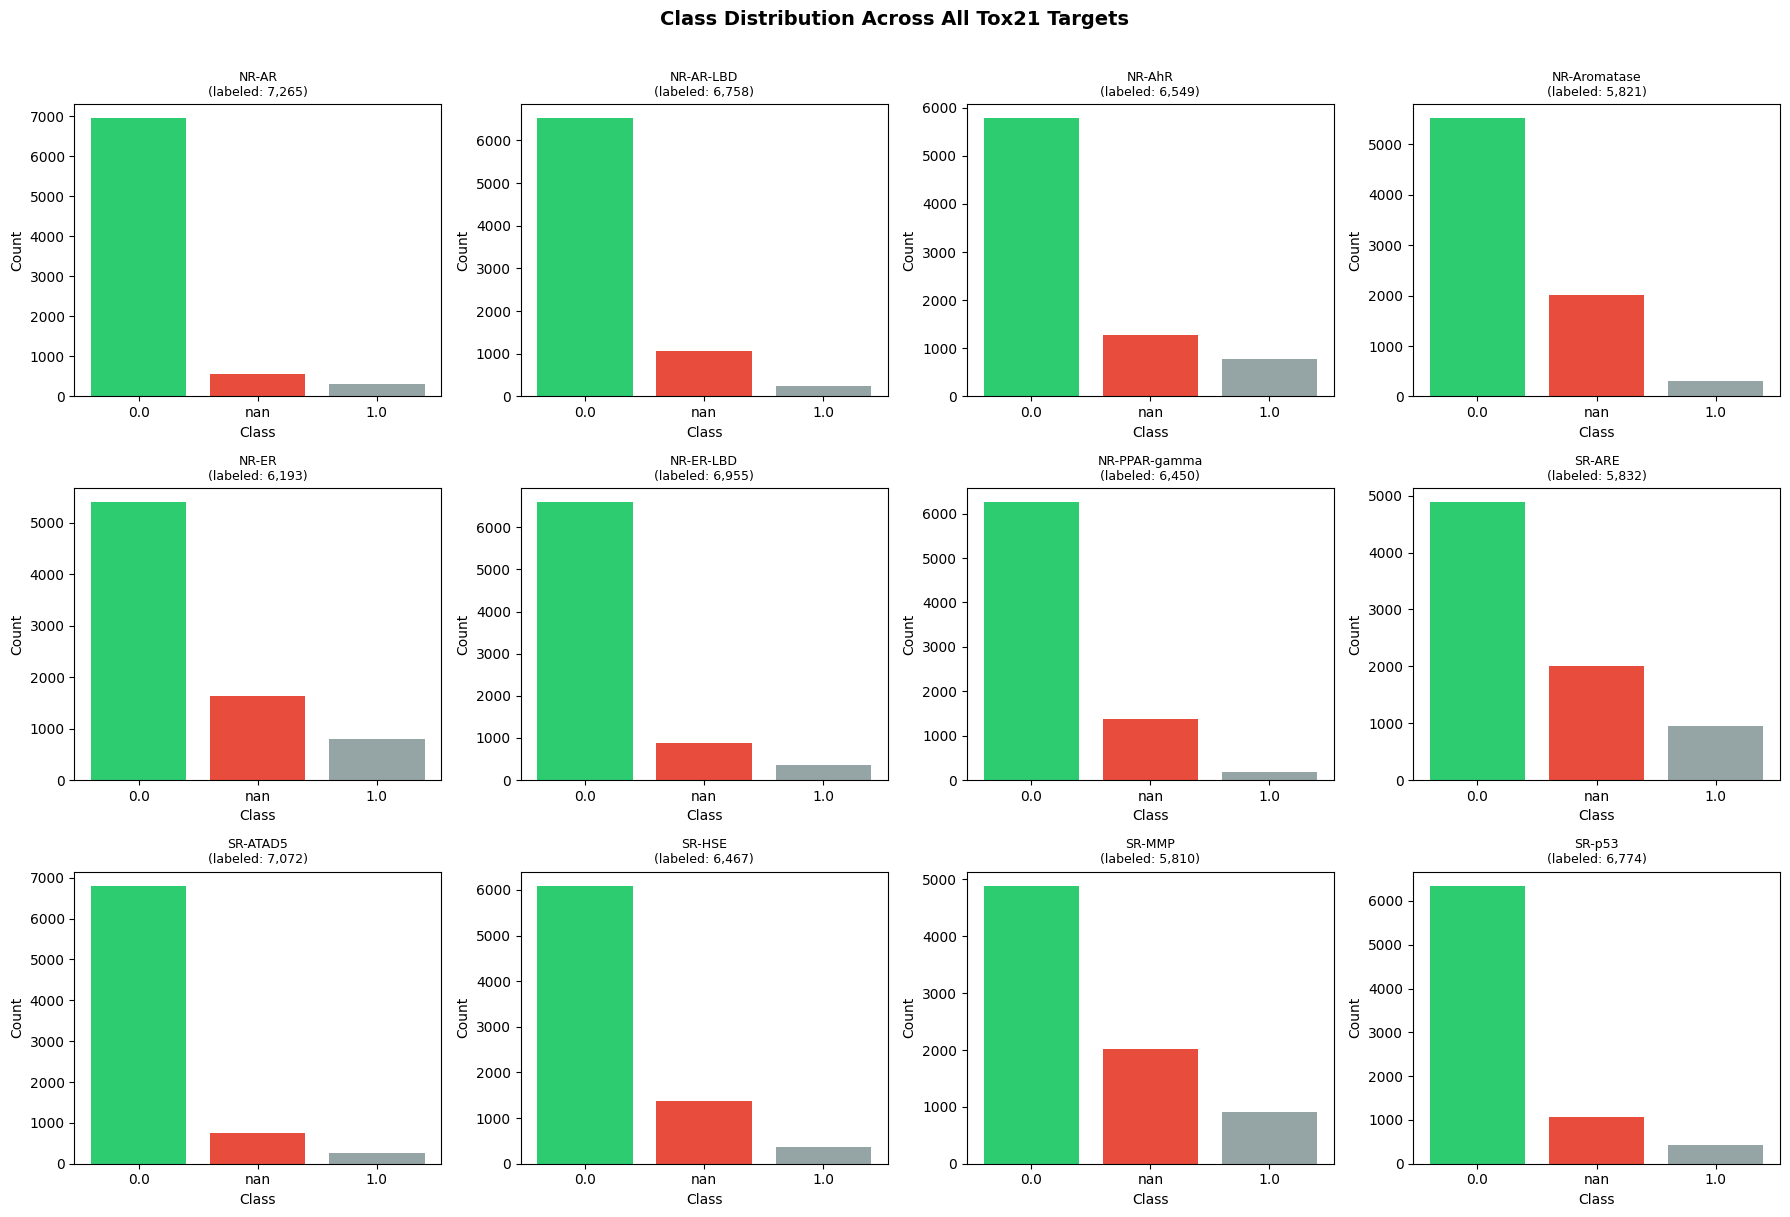

In [26]:
# Visualize class imbalance across all targets
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    if i < len(axes):
        counts = df[col].value_counts(dropna=False)
        labels = [f'{v}' for v in counts.index]
        axes[i].bar(labels, counts.values, color=['#2ecc71', '#e74c3c', '#95a5a6'])
        axes[i].set_title(f'{col}\n(labeled: {df[col].notna().sum():,})', fontsize=9)
        axes[i].set_xlabel('Class')
        axes[i].set_ylabel('Count')

'''for j in range(i+1, len(axes)):
    axes[j].set_visible(False)'''

plt.suptitle('Class Distribution Across All Tox21 Targets', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
      

In [ ]:
valid_smiles = df['smiles'].dropna().head(8).tolist()
mol_objs = [Chem.MolFrom]

NR-AR
0.0    6956
NaN     566
1.0     309
Name: count, dtype: int64

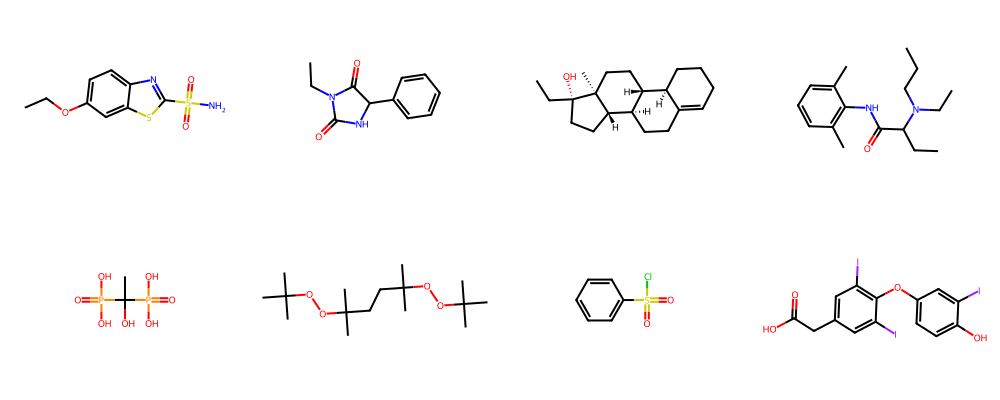

In [29]:
valid_smiles = df['smiles'].dropna().head(8).tolist()
mol_objs = [Chem.MolFromSmiles(s) for s in valid_smiles]
mol_objs = [m for m in mol_objs if m is not None]
img = Draw.MolsToGridImage(mol_objs, molsPerRow=4, subImgSize=(250, 200))
display(img)

## 3. Feature Engineering

We extract two types of features:
- **Molecular Descriptors**: physicochemical properties (MW, LogP, TPSA, etc.)
- **Morgan Fingerprints**: circular fingerprints encoding local chemical environments (2048 bits, radius=2)

In [30]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * 12
    return [

        Descriptors.MolWt(mol),              # Molecular weight
        Descriptors.MolLogP(mol),            # Lipophilicity
        Descriptors.NumHDonors(mol),         # H-bond donors
        Descriptors.NumHAcceptors(mol),      # H-bond acceptors
        Descriptors.NumRotatableBonds(mol),  # Flexibility
        Descriptors.NumAromaticRings(mol),   # Aromaticity
        Descriptors.TPSA(mol),              # Topological polar surface area
        mol.GetNumAtoms(),                   # Atom count
        Descriptors.FractionCSP3(mol),       # Fraction sp3 carbons
        Descriptors.NumHeteroatoms(mol),     # Heteroatom count
        Descriptors.RingCount(mol),          # Ring count
        Descriptors.MolMR(mol),              # Molar refractivity
    ]

DESCRIPTOR_NAMES = [
    'MolWt', 'LogP', 'HBD', 'HBA', 'RotBonds', 'AromaticRings',
    'TPSA', 'NumAtoms', 'FracCSP3', 'HeteroAtoms', 'RingCount', 'MolMR'
]

print('Computing molecular descriptors...')
desc_matrix = np.array(df['smiles'].apply(compute_descriptors).tolist())
df_desc = pd.DataFrame(desc_matrix, columns=DESCRIPTOR_NAMES)
print(f'Descriptor matrix shape: {df_desc.shape}')
display(df_desc.describe().round(2))

Computing molecular descriptors...


[18:55:36] WARNING: not removing hydrogen atom without neighbors
[18:55:38] Explicit valence for atom # 8 Al, 6, is greater than permitted
[18:55:39] Explicit valence for atom # 3 Al, 6, is greater than permitted
[18:55:39] Explicit valence for atom # 4 Al, 6, is greater than permitted
[18:55:41] Explicit valence for atom # 4 Al, 6, is greater than permitted
[18:55:42] Explicit valence for atom # 9 Al, 6, is greater than permitted
[18:55:42] Explicit valence for atom # 5 Al, 6, is greater than permitted
[18:55:44] Explicit valence for atom # 16 Al, 6, is greater than permitted
[18:55:45] Explicit valence for atom # 20 Al, 6, is greater than permitted


Descriptor matrix shape: (7831, 12)


,MolWt,LogP,HBD,HBA,RotBonds,AromaticRings,TPSA,NumAtoms,FracCSP3,HeteroAtoms,RingCount,MolMR
count,7823.00,7823.00,7823.00,7823.00,7823.00,7823.0,7823.00,7823.00,7823.00,7823.00,7823.00,7823.00
mean,276.14,2.37,1.22,3.47,4.30,1.1,59.47,18.57,0.46,4.96,1.77,72.14
std,164.73,2.30,1.92,3.12,4.46,1.1,57.79,11.31,0.33,4.04,1.67,41.78
min,9.01,-17.41,0.00,0.00,0.00,0.0,0.00,1.00,0.00,0.00,0.00,0.00
25%,165.24,1.15,0.00,2.00,1.00,0.0,26.30,11.00,0.18,2.00,1.00,43.82
50%,240.30,2.37,1.00,3.00,3.00,1.0,46.53,16.00,0.42,4.00,1.00,63.67
75%,343.04,3.65,2.00,4.00,6.00,2.0,77.03,23.00,0.73,6.00,3.00,91.06
max,1877.66,22.61,30.00,46.00,47.00,12.0,777.98,132.00,1.00,49.00,30.00,453.37


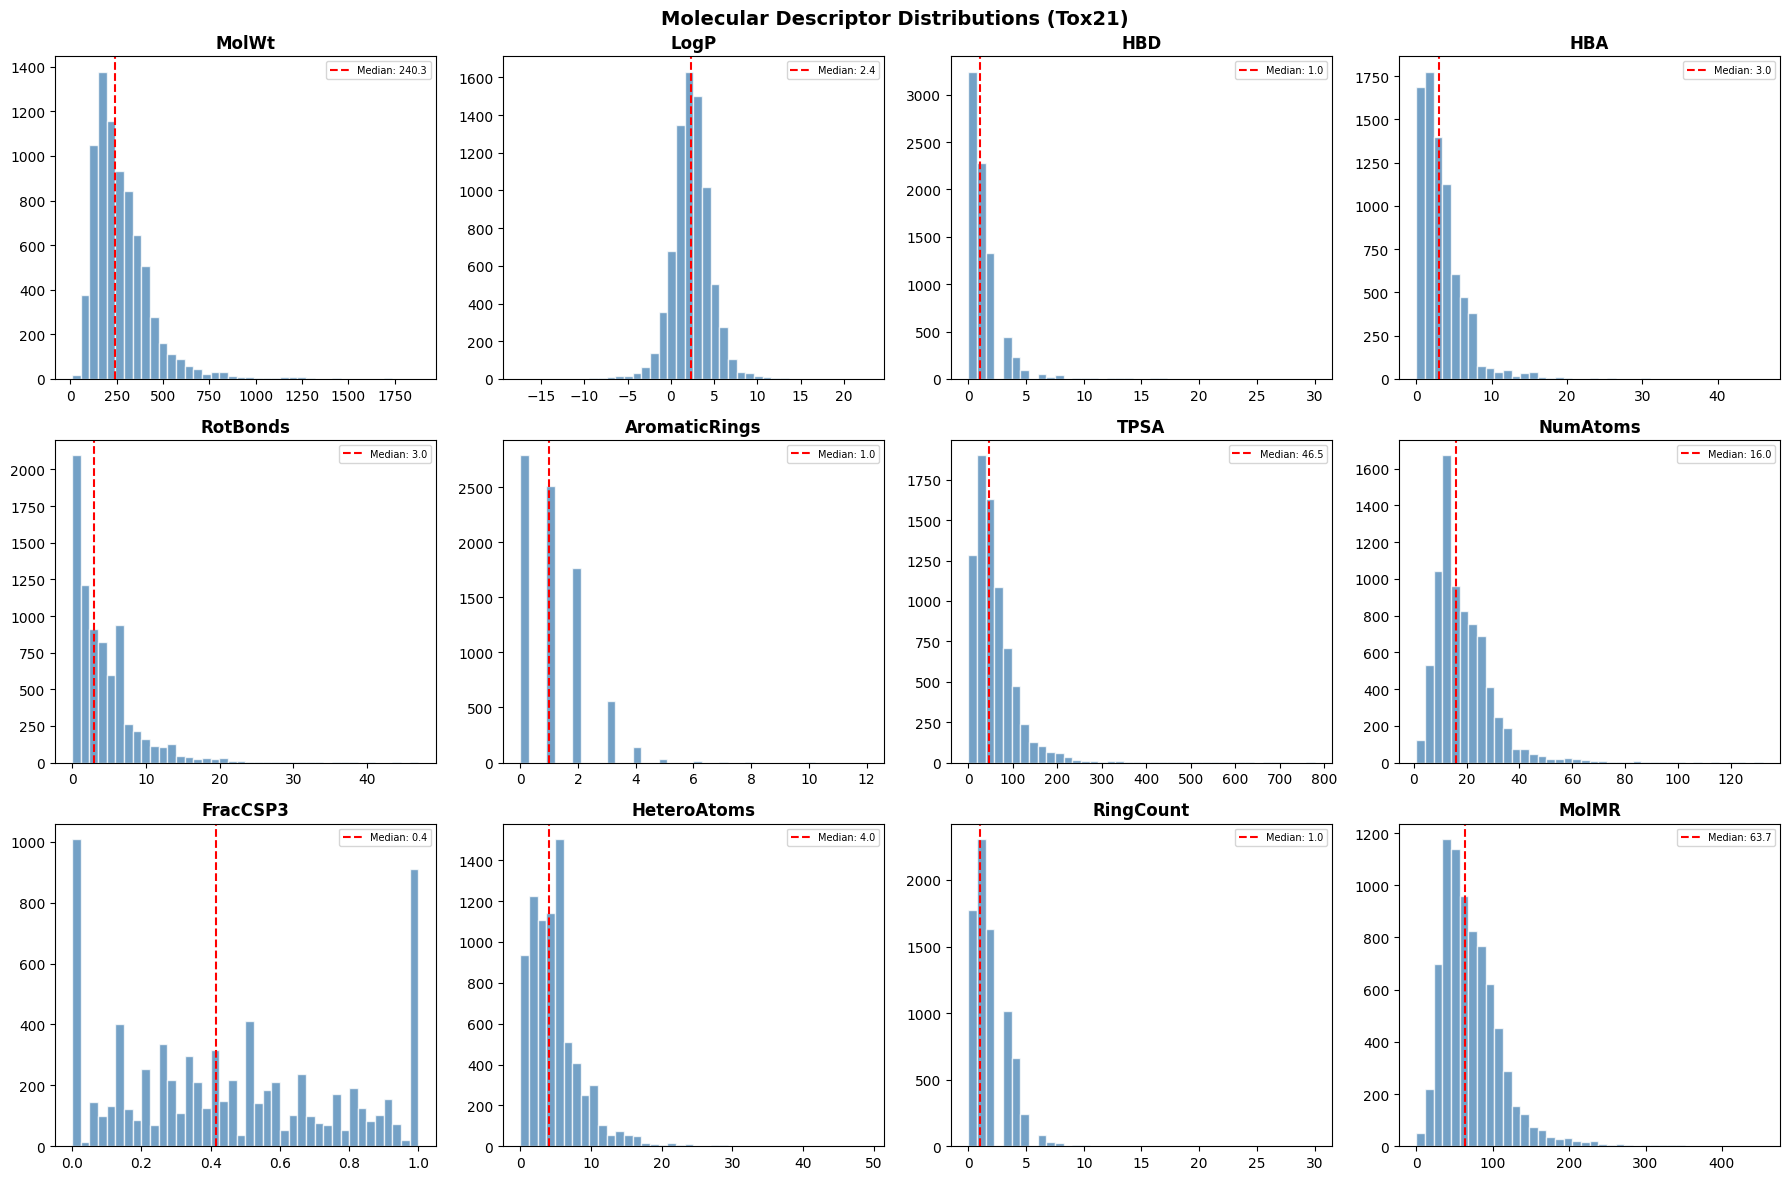

In [31]:
# Plot descriptor distributions
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, desc in enumerate(DESCRIPTOR_NAMES):
    data = df_desc[desc].dropna()
    axes[i].hist(data, bins=40, alpha=0.75, color='steelblue', edgecolor='white')
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].set_title(desc, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle('Molecular Descriptor Distributions (Tox21)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('descriptor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Generate Morgan Fingerprints 
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius = 2,  fpSize = 2048)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None :
        return [0]*2048
    return list(morgan_gen.GetFingerprint(mol))

X_fps = np.array(df['smiles'].apply(get_fingerprint).tolist())
print(f'Fingerprint matrix shape: {X_fps.shape}')
print(f'Sparsity (fraction zero bits): {(X_fps == 0).mean():.3f}')

[19:28:03] WARNING: not removing hydrogen atom without neighbors
[19:28:05] Explicit valence for atom # 8 Al, 6, is greater than permitted
[19:28:07] Explicit valence for atom # 3 Al, 6, is greater than permitted
[19:28:07] Explicit valence for atom # 4 Al, 6, is greater than permitted
[19:28:10] Explicit valence for atom # 4 Al, 6, is greater than permitted
[19:28:12] Explicit valence for atom # 9 Al, 6, is greater than permitted
[19:28:12] Explicit valence for atom # 5 Al, 6, is greater than permitted
[19:28:14] Explicit valence for atom # 16 Al, 6, is greater than permitted
[19:28:16] Explicit valence for atom # 20 Al, 6, is greater than permitted


Fingerprint matrix shape: (7831, 2048)
Sparsity (fraction zero bits): 0.985


In [33]:
np.array(df['smiles'].apply(get_fingerprint).tolist())

[19:28:26] WARNING: not removing hydrogen atom without neighbors
[19:28:29] Explicit valence for atom # 8 Al, 6, is greater than permitted
[19:28:31] Explicit valence for atom # 3 Al, 6, is greater than permitted
[19:28:31] Explicit valence for atom # 4 Al, 6, is greater than permitted
[19:28:33] Explicit valence for atom # 4 Al, 6, is greater than permitted
[19:28:35] Explicit valence for atom # 9 Al, 6, is greater than permitted
[19:28:36] Explicit valence for atom # 5 Al, 6, is greater than permitted
[19:28:37] Explicit valence for atom # 16 Al, 6, is greater than permitted
[19:28:39] Explicit valence for atom # 20 Al, 6, is greater than permitted


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(7831, 2048))

In [35]:
X_fps.shape

(7831, 2048)

In [36]:
df_desc

,MolWt,LogP,HBD,HBA,RotBonds,AromaticRings,TPSA,NumAtoms,FracCSP3,HeteroAtoms,RingCount,MolMR
0,258.324,1.34240,1.0,5.0,3.0,2.0,82.28,16.0,0.222222,7.0,2.0,62.1622
1,204.229,1.29940,1.0,2.0,2.0,1.0,49.41,15.0,0.272727,4.0,2.0,55.1017
2,288.475,5.09030,1.0,1.0,1.0,0.0,20.23,21.0,0.900000,1.0,4.0,86.9438
3,276.424,3.75244,1.0,2.0,7.0,1.0,32.34,20.0,0.588235,3.0,1.0,86.1627
4,206.027,-0.99220,5.0,3.0,2.0,0.0,135.29,11.0,1.000000,9.0,0.0,34.7120
...,...,...,...,...,...,...,...,...,...,...,...,...
7826,440.463,4.02860,2.0,6.0,7.0,5.0,118.81,33.0,0.125000,9.0,5.0,122.0130
7827,314.469,4.72350,0.0,2.0,1.0,0.0,34.14,23.0,0.809524,2.0,4.0,90.8810
7828,288.431,3.87920,1.0,2.0,0.0,0.0,37.30,21.0,0.842105,2.0,4.0,82.7168
7829,272.388,3.60920,2.0,2.0,0.0,1.0,40.46,20.0,0.666667,2.0,4.0,78.7306


In [37]:
X_desc = df_desc.fillna(0).values 
X_combined = np.hstack([X_desc , X_fps])
FEATURE_NAMES = DESCRIPTOR_NAMES + [f'FP_{i}' for i in range(2048)]

print(f'Combined feature matrix: {X_combined.shape}')
print(f'  - Molecular descriptors: {X_desc.shape[1]}')
print(f'  - Morgan fingerprint bits: {X_fps.shape[1]}')

Combined feature matrix: (7831, 2060)
  - Molecular descriptors: 12
  - Morgan fingerprint bits: 2048


## 4. Model Training & Evaluation

Trained 3 models per toxicity target:
- **XGBoost** 
- **Random Forest** 
- **Logistic Regression** 

Using **SMOTE** to handle class imbalance and evaluate using **ROC-AUC** and **PR-AUC**.

In [43]:
MIN_POSITIVE = 50 
viable_targets = []

for target in target_cols :
    pos = (df[target] == 1).sum()
    total = df[target].notna().sum()
    if pos >= MIN_POSITIVE and total >= 200 :
        viable_targets.append({'target': target, 'positives': pos ,'total': total, 'pos_rate': pos/total})
    
viable_df = pd.DataFrame(viable_targets).sort_values('pos_rate' , ascending=False)
print(f"Viable targets for modeling : {len(viable_df)}")
display(viable_df)

Viable targets for modeling : 12


,target,positives,total,pos_rate
7,SR-ARE,942,5832,0.161523
10,SR-MMP,918,5810,0.158003
4,NR-ER,793,6193,0.128048
2,NR-AhR,768,6549,0.117270
11,SR-p53,423,6774,0.062445
9,SR-HSE,372,6467,0.057523
3,NR-Aromatase,300,5821,0.051538
5,NR-ER-LBD,350,6955,0.050324
0,NR-AR,309,7265,0.042533
8,SR-ATAD5,264,7072,0.037330


In [44]:
def train_and_evaluate(X_train, X_test, y_train, y_test, target_name):
    """Train XGBoost, Random Forest, Logistic Regression and return results."""
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    # Apply SMOTE to training set only
    smote = SMOTE(random_state=42, k_neighbors=min(5, (y_train==1).sum()-1))
    try:
        X_res, y_res = smote.fit_resample(X_train_sc, y_train)
    except Exception:
        X_res, y_res = X_train_sc, y_train  # fallback if SMOTE fails

    scale_pos = max(1, (y_train == 0).sum() / max(1, (y_train == 1).sum()))
    
    models = {
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            scale_pos_weight=scale_pos, use_label_encoder=False,
            eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
        ),
        'LogisticRegression': LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42
        )
    }

    results = {}
    for name, model in models.items():
        model.fit(X_res, y_res)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        results[name] = {
            'model': model, 'scaler': scaler,
            'y_prob': y_prob, 'roc_auc': roc_auc, 'pr_auc': pr_auc
        }
        print(f'  {name:20s} | ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}')

    return results


In [45]:
# Train on top 5 targets (or all viable)
TOP_N = 5
top_targets = viable_df.head(TOP_N)['target'].tolist()

all_results = {}
trained_models = {}  # Store best models for SHAP
X_test_store = {}    # Store test sets for SHAP

for target in top_targets:
    print(f'\n{'='*55}')
    print(f'  TARGET: {target}')
    print('='*55)

    mask = df[target].notna()
    X_t = X_combined[mask]
    y_t = df.loc[mask, target].values

    X_train, X_test, y_train, y_test = train_test_split(
        X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
    )
    print(f'  Train: {len(y_train)} | Test: {len(y_test)} | '
          f'Pos rate: {y_train.mean():.2%}')

    results = train_and_evaluate(X_train, X_test, y_train, y_test, target)
    all_results[target] = {'results': results, 'y_test': y_test}

    # Store best model (XGBoost) for SHAP
    scaler = results['XGBoost']['scaler']
    trained_models[target] = results['XGBoost']['model']
    X_test_store[target] = scaler.transform(X_test)

print('\nTraining complete!')


  TARGET: SR-ARE
  Train: 4665 | Test: 1167 | Pos rate: 16.16%
  XGBoost              | ROC-AUC: 0.8234 | PR-AUC: 0.5405
  RandomForest         | ROC-AUC: 0.8521 | PR-AUC: 0.6071
  LogisticRegression   | ROC-AUC: 0.7469 | PR-AUC: 0.3941

  TARGET: SR-MMP
  Train: 4648 | Test: 1162 | Pos rate: 15.79%
  XGBoost              | ROC-AUC: 0.9229 | PR-AUC: 0.7147
  RandomForest         | ROC-AUC: 0.9130 | PR-AUC: 0.7159
  LogisticRegression   | ROC-AUC: 0.7831 | PR-AUC: 0.5011

  TARGET: NR-ER
  Train: 4954 | Test: 1239 | Pos rate: 12.80%
  XGBoost              | ROC-AUC: 0.7045 | PR-AUC: 0.4569
  RandomForest         | ROC-AUC: 0.7099 | PR-AUC: 0.3832
  LogisticRegression   | ROC-AUC: 0.6164 | PR-AUC: 0.2232

  TARGET: NR-AhR
  Train: 5239 | Test: 1310 | Pos rate: 11.72%
  XGBoost              | ROC-AUC: 0.8994 | PR-AUC: 0.6288
  RandomForest         | ROC-AUC: 0.9152 | PR-AUC: 0.6476
  LogisticRegression   | ROC-AUC: 0.8058 | PR-AUC: 0.4302

  TARGET: SR-p53
  Train: 5419 | Test: 1355 | Po

## 5. Results Summary & Visualization

In [46]:
# Build summary dataframe
rows = []
for target, data in all_results.items():
    for model_name, res in data['results'].items():
        rows.append({
            'Target': target,
            'Model': model_name,
            'ROC_AUC': res['roc_auc'],
            'PR_AUC': res['pr_auc']
        })

summary_df = pd.DataFrame(rows)
pivot = summary_df.pivot_table(index='Target', columns='Model', values='ROC_AUC')
print('ROC-AUC by Target and Model:')
display(pivot.round(4))

best_per_target = summary_df.loc[summary_df.groupby('Target')['ROC_AUC'].idxmax()]
print(f'\nAverage Best ROC-AUC: {best_per_target["ROC_AUC"].mean():.4f}')

ROC-AUC by Target and Model:


Model,LogisticRegression,RandomForest,XGBoost
Target,,,
NR-AhR,0.8058,0.9152,0.8994
NR-ER,0.6164,0.7099,0.7045
SR-ARE,0.7469,0.8521,0.8234
SR-MMP,0.7831,0.9130,0.9229
SR-p53,0.6913,0.8619,0.8285



Average Best ROC-AUC: 0.8524


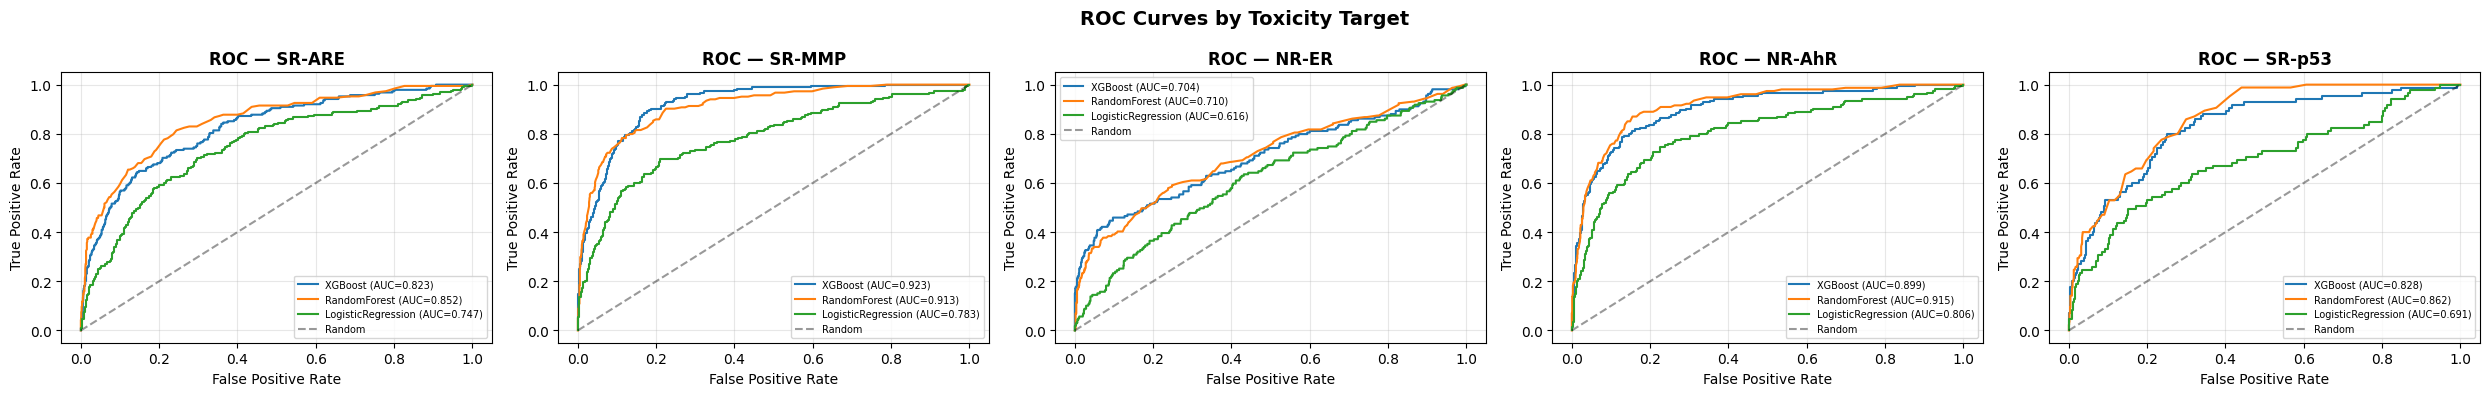

In [47]:
# ROC Curves for all targets (XGBoost only)
fig, axes = plt.subplots(1, len(top_targets), figsize=(5*len(top_targets), 4))
if len(top_targets) == 1:
    axes = [axes]

for ax, target in zip(axes, top_targets):
    y_test = all_results[target]['y_test']
    for model_name, res in all_results[target]['results'].items():
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        ax.plot(fpr, tpr, label=f"{model_name} (AUC={res['roc_auc']:.3f})")
    ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {target}', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves by Toxicity Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

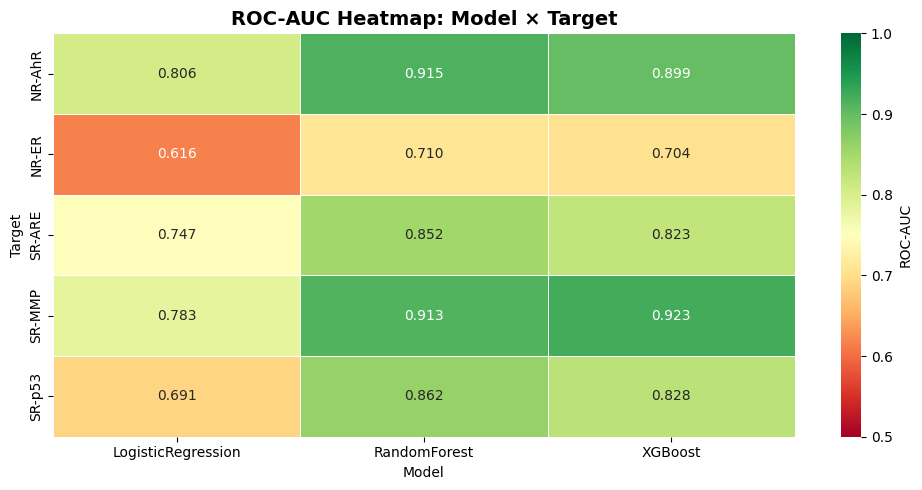

In [48]:
# Heatmap: AUC across models and targets
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.5, cbar_kws={'label': 'ROC-AUC'})
plt.title('ROC-AUC Heatmap: Model × Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Single Compound Prediction Function

A simple prediction interface: input a SMILES string, get toxicity probabilities across all trained targets.

In [50]:
def predict_toxicity(smiles_input):
    """
    Predict toxicity for a single compound given its SMILES string.
    Returns probability scores for each trained target using the XGBoost models.
    """
    mol = Chem.MolFromSmiles(smiles_input)
    if mol is None:
        print(f'ERROR: Invalid SMILES string — "{smiles_input}"')
        return None

    # Compute features
    descriptors = np.array(compute_descriptors(smiles_input)).reshape(1, -1)
    fingerprint = np.array(get_fingerprint(smiles_input)).reshape(1, -1)
    X_input = np.hstack([descriptors, fingerprint])

    predictions = {}
    for target in top_targets:
        model = trained_models[target]
        scaler = all_results[target]['results']['XGBoost']['scaler']
        X_sc = scaler.transform(X_input)
        prob = model.predict_proba(X_sc)[0][1]
        predictions[target] = prob

    # Display result
    print(f'\nToxicity Prediction for: {smiles_input}')
    print(f'{'Target':<30} {'Tox Probability':>18} {'Risk Level':>12}')
    print('-' * 62)
    for target, prob in sorted(predictions.items(), key=lambda x: -x[1]):
        risk = 'HIGH' if prob >= 0.7 else 'MEDIUM' if prob >= 0.4 else 'LOW'
        bar = '█' * int(prob * 20)
        print(f'{target:<30} {prob:>15.1%}    {risk:>8}  {bar}')

    return predictions

# Test with Aspirin
aspirin_smiles = 'CC(=O)Oc1ccccc1C(=O)O'
print('--- Aspirin ---')
predict_toxicity(aspirin_smiles)

--- Aspirin ---

Toxicity Prediction for: CC(=O)Oc1ccccc1C(=O)O
Target                            Tox Probability   Risk Level
--------------------------------------------------------------
NR-ER                                    26.7%         LOW  █████
SR-ARE                                   17.7%         LOW  ███
NR-AhR                                   14.6%         LOW  ██
SR-p53                                   12.9%         LOW  ██
SR-MMP                                    7.8%         LOW  █


{'SR-ARE': np.float32(0.17710142),
 'SR-MMP': np.float32(0.07755373),
 'NR-ER': np.float32(0.26670748),
 'NR-AhR': np.float32(0.14613119),
 'SR-p53': np.float32(0.12922086)}

In [51]:
# Test with Caffeine
caffeine_smiles = 'Cn1cnc2c1c(=O)n(C)c(=O)n2C'
print('--- Caffeine ---')
predict_toxicity(caffeine_smiles)

--- Caffeine ---

Toxicity Prediction for: Cn1cnc2c1c(=O)n(C)c(=O)n2C
Target                            Tox Probability   Risk Level
--------------------------------------------------------------
SR-ARE                                   54.3%      MEDIUM  ██████████
NR-ER                                    29.9%         LOW  █████
SR-p53                                   12.1%         LOW  ██
SR-MMP                                   12.0%         LOW  ██
NR-AhR                                   11.0%         LOW  ██


{'SR-ARE': np.float32(0.5426563),
 'SR-MMP': np.float32(0.12012999),
 'NR-ER': np.float32(0.2986758),
 'NR-AhR': np.float32(0.10979295),
 'SR-p53': np.float32(0.12077948)}

In [52]:
# Test Ethoxzolamide
smiles = 'CCOc1ccc2nc(S(N)(=O)=O)sc2c1'
print('--- Ethoxzolamide ---')
predict_toxicity(smiles)

--- Ethoxzolamide ---

Toxicity Prediction for: CCOc1ccc2nc(S(N)(=O)=O)sc2c1
Target                            Tox Probability   Risk Level
--------------------------------------------------------------
NR-AhR                                   74.5%        HIGH  ██████████████
NR-ER                                    48.2%      MEDIUM  █████████
SR-p53                                   44.7%      MEDIUM  ████████
SR-ARE                                   37.0%         LOW  ███████
SR-MMP                                   24.9%         LOW  ████


{'SR-ARE': np.float32(0.370074),
 'SR-MMP': np.float32(0.24920873),
 'NR-ER': np.float32(0.48227265),
 'NR-AhR': np.float32(0.74514174),
 'SR-p53': np.float32(0.4473341)}